# Wilcoxon signed-rank test (paired samples)

Passive: N paired = 20
Active: N paired = 20
Passive: 0.0
Active: 0.0


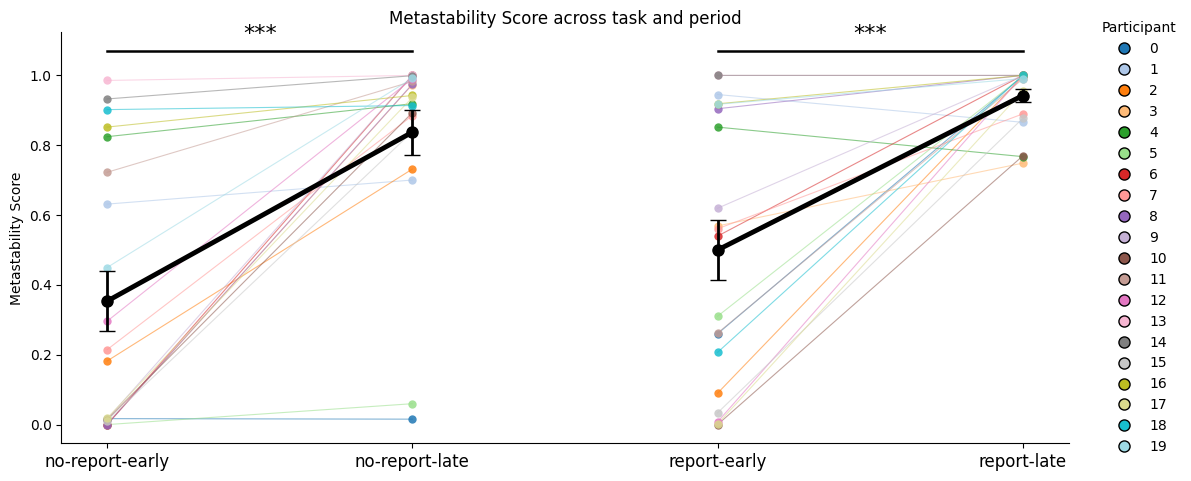

Passive: N paired = 20
Active: N paired = 20
Passive: 0.002
Active: 0.0003


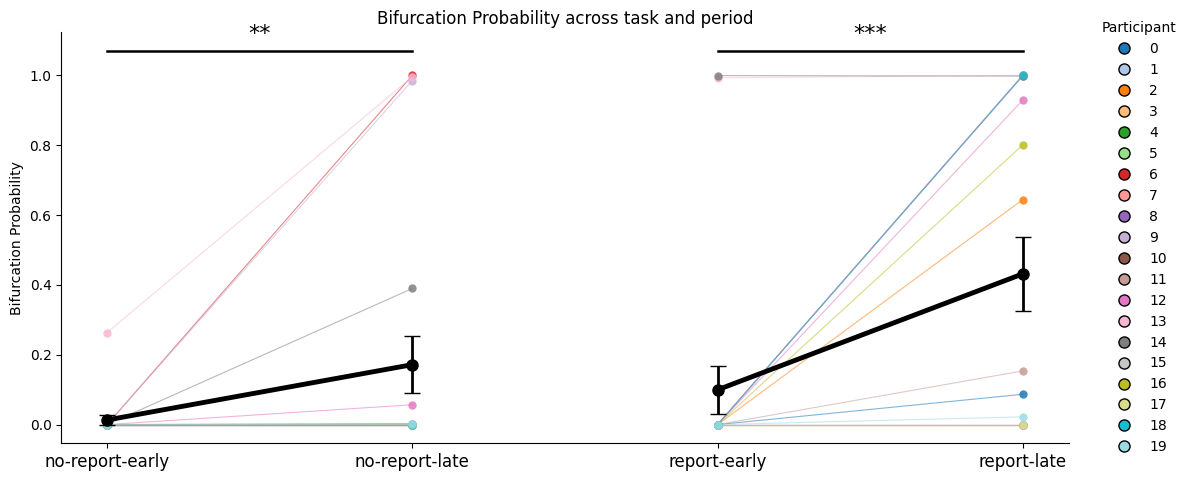

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import wilcoxon
from matplotlib.lines import Line2D

import os
repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

# =======================
# Configuration
# =======================

conditions = [
    ("Passive", "early"),
    ("Passive", "late"),
    ("Active", "early"),
    ("Active", "late"),
]

condition_order = [
    "Passive-early",
    "Passive-late",
    "Active-early",
    "Active-late",
]

# =======================
# Load data
# =======================
dfs = []

for task, period in conditions:
    base_path = Path(f"Fit_{task}_{period}")
    csv_path = base_path / "MetaBifurc_AllModels_21^2" / "metabifurc.csv"
    df = pd.read_csv(csv_path, index_col=0)
    
    df["SubID"] = df.index
    df["task"] = task
    df["period"] = period
    df["condition"] = f"{task}-{period}"
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# =======================
# Plot label mapping (for plotting only)
# =======================
map_task = {"Passive": "no-report", "Active": "report"}
data["task_plot"] = data["task"].map(map_task)
data["condition_plot"] = data["task_plot"] + '-' + data["period"]

condition_order_plot = [
    "no-report-early",
    "no-report-late",
    "report-early",
    "report-late",
]

# =======================
# Styling
# =======================
# sns.set_theme(style="whitegrid", context="talk")

subids = sorted(data["SubID"].unique())
palette = sns.color_palette("tab20", len(subids))
subid_color = dict(zip(subids, palette))

# =======================
# Plot 1: metastability score across conditions
# =======================
fig, ax = plt.subplots(figsize=(12, 5))

# ---- Pairing lines (early → late within task)
for task in ["Passive", "Active"]:
    early = data[(data.task == task) & (data.period == "early")]
    late  = data[(data.task == task) & (data.period == "late")]

    for sub in set(early.SubID).intersection(late.SubID):
        y1 = early.loc[early.SubID == sub, "metastability_score"].values[0]
        y2 = late.loc[late.SubID == sub, "metastability_score"].values[0]
        x1 = condition_order_plot.index(f"{map_task[task]}-early")
        x2 = condition_order_plot.index(f"{map_task[task]}-late")

        ax.plot(
            [x1, x2], [y1, y2],
            color=subid_color[sub], alpha=0.55, linewidth=0.8, zorder=1
        )

# ---- Rain (points only), colored by subject
for sub, df_sub in data.groupby("SubID"):
    sns.stripplot(
        data=df_sub,
        x="condition_plot",
        y="metastability_score",
        order=condition_order_plot,
        jitter=0.18,
        size=6,
        alpha=0.85,
        color=subid_color[sub],
        ax=ax,
        zorder=2
    )

# ---- Mean ± SEM
stats = (
    data.groupby("condition_plot")["metastability_score"]
    .agg(["mean", "sem"])
    .reindex(condition_order_plot)
)

x = np.arange(len(condition_order_plot))

# Bold black mean connector lines within each task
ax.plot([0, 1], [stats.loc["no-report-early", "mean"], stats.loc["no-report-late", "mean"]],
        color="black", linewidth=3.5, zorder=2.6)
ax.plot([2, 3], [stats.loc["report-early", "mean"], stats.loc["report-late", "mean"]],
        color="black", linewidth=3.5, zorder=2.6)

ax.errorbar(
    x=x,
    y=stats["mean"],
    yerr=stats["sem"],
    fmt="o",
    color="black",
    capsize=6,
    markersize=8,
    linewidth=2,
    zorder=3
)

# =======================
# Statistics
# =======================
def paired_p(task):

    e = data[(data.task == task) & (data.period == "early")]
    l = data[(data.task == task) & (data.period == "late")]

    # Set SubID as index for alignment
    e = e.set_index("SubID")
    l = l.set_index("SubID")

    # Keep only subjects present in BOTH
    common = e.index.intersection(l.index)

    # Align explicitly
    e_vals = e.loc[common, "metastability_score"]
    l_vals = l.loc[common, "metastability_score"]

    # Remove any NaNs just in case
    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid]
    l_vals = l_vals[valid]

    print(f"{task}: N paired = {len(e_vals)}")

    if len(e_vals) < 2:
        print(f"{task}: Not enough paired data.")
        return np.nan

    _, p = wilcoxon(e_vals, l_vals)
    return p

def paired_p_permutation(task, n_permutations=10000, seed=0):

    e = data[(data.task == task) & (data.period == "early")]
    l = data[(data.task == task) & (data.period == "late")]

    # Set SubID as index for alignment
    e = e.set_index("SubID")
    l = l.set_index("SubID")

    # Keep only subjects present in BOTH
    common = e.index.intersection(l.index)

    # Align explicitly
    e_vals = e.loc[common, "metastability_score"]
    l_vals = l.loc[common, "metastability_score"]

    # Remove any NaNs just in case
    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid].to_numpy()
    l_vals = l_vals[valid].to_numpy()

    print(f"{task}: N paired = {len(e_vals)}")

    if len(e_vals) < 2:
        print(f"{task}: Not enough paired data.")
        return np.nan

    obs_diff = e_vals.mean() - l_vals.mean()
    pair_diffs = e_vals - l_vals

    rng = np.random.default_rng(seed)
    perm_diffs = np.empty(n_permutations)

    for i in range(n_permutations):
        # Swap the two measurements within each pair with probability 0.5
        swap_mask = rng.random(len(pair_diffs)) < 0.5
        permuted_diffs = np.where(swap_mask, -pair_diffs, pair_diffs)
        perm_diffs[i] = permuted_diffs.mean()

    p = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
    return p

paired_test_method = "permutation"  # "wilcoxon" or "permutation"
paired_p_fn = {
    "wilcoxon": paired_p,
    "permutation": paired_p_permutation,
}[paired_test_method]

def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "p=" + str(p)[:5]

p_passive = paired_p_fn("Passive")
p_active  = paired_p_fn("Active")
print(f"Passive: {p_passive}")
print(f"Active: {p_active}")

# ---- Annotations (ONLY if significant)
def annotate(x1, x2, y, text):
    ax.plot([x1, x2], [y, y], color="black", linewidth=1.8)
    ax.text((x1 + x2) / 2, y + 0.02, text,
            ha="center", va="bottom", fontsize=16)

y_top = data["metastability_score"].max() + 0.07

if stars(p_passive):
    annotate(0, 1, y_top, stars(p_passive))

if stars(p_active):
    annotate(2, 3, y_top, stars(p_active))

# =======================
# Participant color legend
# =======================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=str(sub),
        markerfacecolor=subid_color[sub],
        markersize=8
    )
    for sub in subids
]

ax.legend(
    handles=legend_elements,
    title="Participant",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

# =======================
# Final touches
# =======================
ax.set_ylabel("Metastability Score")
ax.set_xlabel("")
# ax.set_ylim(0, 1.15)
ax.set_title("Metastability Score across task and period")
ax.tick_params(axis="x", labelsize=12)

sns.despine()
plt.tight_layout()
# plt.savefig('MetastabilityScoreAcrossConditions_PersoModels.png')
plt.show()





# =======================
# Plot 2: bifurcation probability across conditions
# =======================
fig, ax = plt.subplots(figsize=(12, 5))

# ---- Pairing lines (early → late within task)
for task in ["Passive", "Active"]:
    early = data[(data.task == task) & (data.period == "early")]
    late  = data[(data.task == task) & (data.period == "late")]

    for sub in set(early.SubID).intersection(late.SubID):
        y1 = early.loc[early.SubID == sub, "probability_of_bifurcation"].values[0]
        y2 = late.loc[late.SubID == sub, "probability_of_bifurcation"].values[0]
        x1 = condition_order_plot.index(f"{map_task[task]}-early")
        x2 = condition_order_plot.index(f"{map_task[task]}-late")

        ax.plot(
            [x1, x2], [y1, y2],
            color=subid_color[sub], alpha=0.55, linewidth=0.8, zorder=1
        )

# ---- Rain (points only), colored by subject
for sub, df_sub in data.groupby("SubID"):
    sns.stripplot(
        data=df_sub,
        x="condition_plot",
        y="probability_of_bifurcation",
        order=condition_order_plot,
        jitter=0.18,
        size=6,
        alpha=0.85,
        color=subid_color[sub],
        ax=ax,
        zorder=2
    )

# ---- Mean ± SEM
stats = (
    data.groupby("condition_plot")["probability_of_bifurcation"]
    .agg(["mean", "sem"])
    .reindex(condition_order_plot)
)

x = np.arange(len(condition_order_plot))

# Bold black mean connector lines within each task
ax.plot([0, 1], [stats.loc["no-report-early", "mean"], stats.loc["no-report-late", "mean"]],
        color="black", linewidth=3.5, zorder=2.6)
ax.plot([2, 3], [stats.loc["report-early", "mean"], stats.loc["report-late", "mean"]],
        color="black", linewidth=3.5, zorder=2.6)

ax.errorbar(
    x=x,
    y=stats["mean"],
    yerr=stats["sem"],
    fmt="o",
    color="black",
    capsize=6,
    markersize=8,
    linewidth=2,
    zorder=3
)

# =======================
# Statistics
# =======================
def paired_p(task):

    e = data[(data.task == task) & (data.period == "early")]
    l = data[(data.task == task) & (data.period == "late")]

    # Set SubID as index for alignment
    e = e.set_index("SubID")
    l = l.set_index("SubID")

    # Keep only subjects present in BOTH
    common = e.index.intersection(l.index)

    # Align explicitly
    e_vals = e.loc[common, "probability_of_bifurcation"]
    l_vals = l.loc[common, "probability_of_bifurcation"]

    # Remove any NaNs just in case
    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid]
    l_vals = l_vals[valid]

    print(f"{task}: N paired = {len(e_vals)}")

    if len(e_vals) < 2:
        print(f"{task}: Not enough paired data.")
        return np.nan

    _, p = wilcoxon(e_vals, l_vals)
    return p

def paired_p_permutation(task, n_permutations=10000, seed=0):

    e = data[(data.task == task) & (data.period == "early")]
    l = data[(data.task == task) & (data.period == "late")]

    # Set SubID as index for alignment
    e = e.set_index("SubID")
    l = l.set_index("SubID")

    # Keep only subjects present in BOTH
    common = e.index.intersection(l.index)

    # Align explicitly
    e_vals = e.loc[common, "probability_of_bifurcation"]
    l_vals = l.loc[common, "probability_of_bifurcation"]

    # Remove any NaNs just in case
    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid].to_numpy()
    l_vals = l_vals[valid].to_numpy()

    print(f"{task}: N paired = {len(e_vals)}")

    if len(e_vals) < 2:
        print(f"{task}: Not enough paired data.")
        return np.nan

    obs_diff = e_vals.mean() - l_vals.mean()
    pair_diffs = e_vals - l_vals

    rng = np.random.default_rng(seed)
    perm_diffs = np.empty(n_permutations)

    for i in range(n_permutations):
        # Swap the two measurements within each pair with probability 0.5
        swap_mask = rng.random(len(pair_diffs)) < 0.5
        permuted_diffs = np.where(swap_mask, -pair_diffs, pair_diffs)
        perm_diffs[i] = permuted_diffs.mean()

    p = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
    return p

paired_test_method = "permutation"  # "wilcoxon" or "permutation"
paired_p_fn = {
    "wilcoxon": paired_p,
    "permutation": paired_p_permutation,
}[paired_test_method]

def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "p=" + str(p)[:5]

p_passive = paired_p_fn("Passive")
p_active  = paired_p_fn("Active")
print(f"Passive: {p_passive}")
print(f"Active: {p_active}")

# ---- Annotations (ONLY if significant)
def annotate(x1, x2, y, text):
    ax.plot([x1, x2], [y, y], color="black", linewidth=1.8)
    ax.text((x1 + x2) / 2, y + 0.02, text,
            ha="center", va="bottom", fontsize=16)

y_top = data["probability_of_bifurcation"].max() + 0.07

if stars(p_passive):
    annotate(0, 1, y_top, stars(p_passive))

if stars(p_active):
    annotate(2, 3, y_top, stars(p_active))

# =======================
# Participant color legend
# =======================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=str(sub),
        markerfacecolor=subid_color[sub],
        markersize=8
    )
    for sub in subids
]

ax.legend(
    handles=legend_elements,
    title="Participant",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

# =======================
# Final touches
# =======================
ax.set_ylabel("Bifurcation Probability")
ax.set_xlabel("")
# ax.set_ylim(0, 1.15)
ax.set_title("Bifurcation Probability across task and period")
ax.tick_params(axis="x", labelsize=12)

sns.despine()
plt.tight_layout()
# plt.savefig('BifurcationProbabilityAcrossConditions_PersoModels.png')
plt.show()



In [ ]:
late_data = data[data.period == "late"]
active_late = late_data[late_data.task == "Active"]["metastability_score"]
passive_late = late_data[late_data.task == "Passive"]["metastability_score"]

# Compare Active vs Passive in late condition using a permutation test
rng = np.random.default_rng(0)

obs_diff = active_late.mean() - passive_late.mean()
combined = np.concatenate([active_late.to_numpy(), passive_late.to_numpy()])
n_active = len(active_late)

n_permutations = 10000
perm_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    permuted = rng.permutation(combined)
    perm_active = permuted[:n_active]
    perm_passive = permuted[n_active:]
    perm_diffs[i] = perm_active.mean() - perm_passive.mean()

p_perm = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f"Active (late):  mean = {active_late.mean():.5f}, N = {len(active_late)}")
print(f"Passive (late): mean = {passive_late.mean():.5f}, N = {len(passive_late)}")
print(f"Observed mean difference (Active - Passive) = {obs_diff:.5f}")
print(f"Permutation test p-value = {p_perm:.4f} (n = {n_permutations})")

Active (late):  mean = 0.92317, N = 20
Passive (late): mean = 0.80442, N = 20
Observed mean difference (Active - Passive) = 0.11875
Permutation test p-value = 0.1083 (n = 10000)


In [ ]:
early_data = data[data.period == "early"]
active_early = early_data[early_data.task == "Active"]["metastability_score"]
passive_early = early_data[early_data.task == "Passive"]["metastability_score"]

# Compare Active vs Passive in late condition using a permutation test
rng = np.random.default_rng(0)

obs_diff = active_early.mean() - passive_early.mean()
combined = np.concatenate([active_early.to_numpy(), passive_early.to_numpy()])
n_active = len(active_early)

n_permutations = 10000
perm_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    permuted = rng.permutation(combined)
    perm_active = permuted[:n_active]
    perm_passive = permuted[n_active:]
    perm_diffs[i] = perm_active.mean() - perm_passive.mean()

p_perm = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f"Active (early):  mean = {active_early.mean():.5f}, N = {len(active_early)}")
print(f"Passive (early): mean = {passive_early.mean():.5f}, N = {len(passive_early)}")
print(f"Observed mean difference (Active - Passive) = {obs_diff:.5f}")
print(f"Permutation test p-value = {p_perm:.4f} (n = {n_permutations})")

Active (early):  mean = 0.37482, N = 20
Passive (early): mean = 0.31788, N = 20
Observed mean difference (Active - Passive) = 0.05694
Permutation test p-value = 0.6526 (n = 10000)


In [ ]:
from statsmodels.stats.anova import AnovaRM

# Idea: use a 2x2 repeated-measures ANOVA.
# task = Passive vs Active, period = early vs late
# This tests the main effects of task and period, plus their interaction.
anova_df = data[["SubID", "task", "period", "metastability_score"]].copy()

# Check whether every participant has all 4 conditions.
wide = anova_df.pivot_table(
    index="SubID",
    columns=["task", "period"],
    values="metastability_score",
    aggfunc="mean",
)
complete_subjects = wide.dropna().index
n_total = wide.shape[0]
n_complete = len(complete_subjects)

print(f"Subjects with complete 4-condition data: {n_complete}/{n_total}")

if n_complete < n_total:
    dropped = sorted(set(wide.index) - set(complete_subjects))
    print(f"Dropping incomplete subjects: {dropped}")

anova_df = anova_df[anova_df["SubID"].isin(complete_subjects)].copy()

print("\nCondition means (complete cases only):")
print(
    anova_df.groupby(["task", "period"])["metastability_score"]
    .agg(["mean", "std", "count"])
    .round(5)
)

# Fit the repeated-measures ANOVA.
# With two levels per factor, sphericity is not an issue.
anova_res = AnovaRM(
    anova_df,
    depvar="metastability_score",
    subject="SubID",
    within=["task", "period"],
).fit()

print("\nRepeated-measures ANOVA (2x2 within-subject):")
print(anova_res.anova_table.round(5))

print("\nInterpretation guide:")
print("- task: Passive vs Active overall difference")
print("- period: early vs late overall difference")
print("- task:period: whether the early-to-late change differs by task")
print("- If you have missing cells and want to keep those participants, use a linear mixed-effects model instead of ANOVA.")

Subjects with complete 4-condition data: 20/20

Condition means (complete cases only):
                   mean      std  count
task    period                         
Active  early   0.37482  0.39186     20
        late    0.92317  0.14436     20
Passive early   0.31788  0.41653     20
        late    0.80442  0.28533     20

Repeated-measures ANOVA (2x2 within-subject):
              F Value  Num DF  Den DF   Pr > F
task          2.88121     1.0    19.0  0.10594
period       48.87453     1.0    19.0  0.00000
task:period   0.23906     1.0    19.0  0.63048

Interpretation guide:
- task: Passive vs Active overall difference
- period: early vs late overall difference
- task:period: whether the early-to-late change differs by task
- If you have missing cells and want to keep those participants, use a linear mixed-effects model instead of ANOVA.


In [ ]:
from scipy.stats import ttest_1samp

# Bayes factors from the 2x2 repeated-measures design.
# This uses a BIC approximation (BF10 ≈ exp((BIC_null - BIC_alt)/2)).
# It is a practical approximation when you do not have a dedicated Bayesian ANOVA package installed.

subject_means = anova_df.pivot_table(
    index="SubID",
    columns=["task", "period"],
    values="metastability_score",
    aggfunc="mean",
).sort_index()

# Task main effect: Active averaged over period minus Passive averaged over period.
task_scores = (
    subject_means.xs("Active", level="task", axis=1).mean(axis=1)
    - subject_means.xs("Passive", level="task", axis=1).mean(axis=1)
)

# Period main effect: Late averaged over task minus Early averaged over task.
period_scores = (
    subject_means.xs("late", level="period", axis=1).mean(axis=1)
    - subject_means.xs("early", level="period", axis=1).mean(axis=1)
)

# Interaction: difference-in-differences.
interaction_scores = (
    (subject_means[("Active", "late")] - subject_means[("Active", "early")])
    - (subject_means[("Passive", "late")] - subject_means[("Passive", "early")])
)


def bic_bayes_factor_10(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)

    if n < 2:
        return np.nan

    rss_null = np.sum(values ** 2)
    rss_alt = np.sum((values - values.mean()) ** 2)

    # Guard against numerical issues when the effect is essentially constant.
    rss_null = max(rss_null, np.finfo(float).tiny)
    rss_alt = max(rss_alt, np.finfo(float).tiny)

    bic_null = n * np.log(rss_null / n)
    bic_alt = n * np.log(rss_alt / n) + np.log(n)
    return np.exp((bic_null - bic_alt) / 2)


def report_bf(label, values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    t_res = ttest_1samp(values, 0.0)
    bf10 = bic_bayes_factor_10(values)
    bf01 = 1.0 / bf10 if np.isfinite(bf10) and bf10 != 0 else np.nan
    print(
        f"{label}: t({len(values) - 1}) = {t_res.statistic:.4f}, p = {t_res.pvalue:.5f}, "
        f"BF10 ≈ {bf10:.3f}, BF01 ≈ {bf01:.3f}"
    )

print("Approximate Bayes factors for the 2x2 within-subject effects:")
report_bf("Task main effect", task_scores)
report_bf("Period main effect", period_scores)
report_bf("Task × Period interaction", interaction_scores)

print("\nInterpretation:")
print("- BF10 > 1 favors a real effect; BF10 < 1 favors the null.")
print("- Values around 1 are inconclusive.")
print("- Common rough labels: 1-3 anecdotal, 3-10 moderate, 10-30 strong, >30 very strong.")
print("- These are BIC-based approximations; for exact Bayesian ANOVA, use a dedicated Bayesian model/package.")

Approximate Bayes factors for the 2x2 within-subject effects:
Task main effect: t(19) = 1.6974, p = 0.10594, BF10 ≈ 0.918, BF01 ≈ 1.090
Period main effect: t(19) = 6.9910, p = 0.00000, BF10 ≈ 75686.339, BF01 ≈ 0.000
Task × Period interaction: t(19) = 0.4889, p = 0.63048, BF10 ≈ 0.253, BF01 ≈ 3.947

Interpretation:
- BF10 > 1 favors a real effect; BF10 < 1 favors the null.
- Values around 1 are inconclusive.
- Common rough labels: 1-3 anecdotal, 3-10 moderate, 10-30 strong, >30 very strong.
- These are BIC-based approximations; for exact Bayesian ANOVA, use a dedicated Bayesian model/package.


In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Build total_auc from the existing DataFrame `data`
# Map: SubID -> pp_num, task -> group, period -> SOA, metastability_score -> AUC
total_auc = (
    data[["SubID", "task", "period", "metastability_score"]]
    .rename(columns={
        "SubID": "pp_num",
        "task": "group",
        "period": "SOA",
        "metastability_score": "AUC",
    })
    .dropna(subset=["AUC"])
    .copy()
)

with localconverter(ro.default_converter + pandas2ri.converter):
    rdata = ro.conversion.py2rpy(total_auc)
ro.globalenv["rdata"] = rdata

ro.r("""
library(BayesFactor)
rdata$pp_num <- as.factor(rdata$pp_num)
rdata$group  <- as.factor(rdata$group)
rdata$SOA    <- as.factor(rdata$SOA)

# Run Bayesian ANOVA: AUC ~ group * SOA with subject as random effect
bf_result <- anovaBF(AUC ~ group * SOA + pp_num, data = rdata,
                     whichRandom = "pp_num", whichModels = "withmain")
bf_table <- as.data.frame(bf_result)
print(bf_table)
""")

error: symbol 'R_getVar' not found in library '/usr/lib/R/lib/libR.so': /usr/lib/R/lib/libR.so: undefined symbol: R_getVar